# Jackknife covariance of the 1D power spectrum

After you have measured $P(k)$ with `PowerSpectrum`, you can estimate its covariance by delete-one jackknife resampling of the survey volume. `JackknifeCovariance` uses the same instance (same box, weights, $k$-bins, and taper settings) and removes one patch at a time.

The default estimator grids the map **once**, labels each Cartesian voxel from its centre (RA, Dec, frequency), and zeros those voxels in the delete-one patch. A more expensive route is to first mask out pixels/galaxies within the delete-one patch, and then regrid the map cube and galaxy catalogue, which can be switched on with ``regrid=True``.

This notebook uses a small synthetic map so it runs quickly. On real data, pass the same `PowerSpectrum` instance you used for the measurement.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from meer21cm import PowerSpectrum
from meer21cm.jackknife import JackknifeCovariance
from meer21cm.util import create_wcs, redshift_to_freq

## Build a map and measure $P(k)$

A compact lightcone is enough to show the API. The important part is that the jackknife sees the **same** gridded field, `counts_in_box`, and $k$-bins as the data measurement.

In [2]:
nu = np.linspace(redshift_to_freq(0.45), redshift_to_freq(0.35), 24)
wcs = create_wcs(180.0, -30.0, [32, 32], 0.4)
ps = PowerSpectrum(
    nu=nu,
    wproj=wcs,
    num_pix_x=32,
    num_pix_y=32,
    seed=1,
)
rng = np.random.default_rng(0)
ps.data = rng.normal(size=ps.W_HI.shape)
ps.w_HI = np.ones(ps.W_HI.shape)
ps.set_radecnu_bounds_from_map()

ps.get_enclosing_box()
ps.k1dbins = np.linspace(0.05, 0.35, 7)
ps.field_1, _, _ = ps.grid_data_to_field()
ps.weights_1 = ps.counts_in_box

p1d, keff, nmodes = ps.get_1d_power("auto_power_3d_1")
print(ps.box_ndim, p1d)

[27 27 13] [1543.67422951 1650.21335799 1599.28802481 1579.13487148 1725.24958568
 1462.53110032]


## Delete-one jackknife

Split the survey into $2\times 2\times 2$ patches. `type="auto"` jackknifes the HI auto-power; use `type="cross"` when the instance also has a galaxy catalogue. `pool="serial"` is convenient for a small box; the default is `multiprocessing`.

Match `weights_scheme` and `apply_taper` to the data measurement. The default scheme (`"validation"`) uses jackknifed `counts_in_box` as the HI grid weights, which is what we set above.

In [5]:
jc = JackknifeCovariance(
    ps,
    ra_patch_num=2, # split in RA
    dec_patch_num=2, # split in Dec
    los_patch_num=2, # split in frequency
    pool="serial", # can be parallel
)
print("patch weight fractions:", jc.patch_weight_fraction())

results = jc.run(type="auto")
cov, mean_p1d = jc.get_covariance(results)
sigma = np.sqrt(np.diag(cov))
print("N patches used:", len(jc.patch_indices_used))
print("mean P(k):", mean_p1d)
print("sigma_JK:", sigma)

patch weight fractions: [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
N patches used: 8
mean P(k): [1482.49022937 1503.02712289 1551.47115984 1479.88823079 1634.65440952
 1316.14260439]
sigma_JK: [200.45370587 121.57694059  71.22631689  42.57285114 199.49055673
 205.23008249]


The covariance is the standard estimator

$$
C = \frac{N-1}{N}\sum_{j=1}^{N}(P_j-\bar P)(P_j-\bar P)^{\!T}.
$$

`mean_p1d` is the average of the delete-one spectra, `cov` is the calculated jackknife covariance. Use the full-sample measurement for the data vector and $C$ for its covariance.

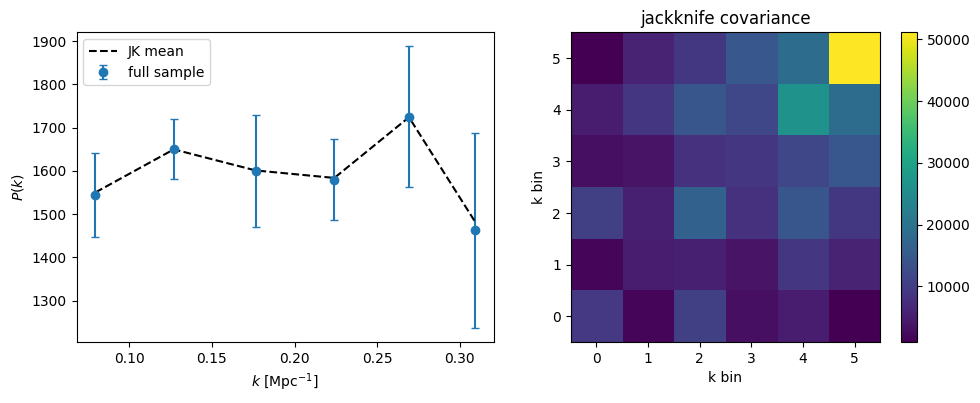

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].errorbar(keff, p1d, yerr=sigma, fmt="o", capsize=3, label="full sample")
axes[0].plot(keff, mean_p1d, "k--", label="JK mean")
axes[0].set_xlabel(r"$k$ [Mpc$^{-1}$]")
axes[0].set_ylabel(r"$P(k)$")
axes[0].legend()

im = axes[1].imshow(cov, origin="lower")
axes[1].set_title("jackknife covariance")
axes[1].set_xlabel("k bin")
axes[1].set_ylabel("k bin")
fig.colorbar(im, ax=axes[1])
plt.tight_layout()

## Notes

- **HI × galaxy.** `jc.run(type="cross")` zeros the same box voxels in both painted fields. With `return_auto_power=True` each realisation also returns the two auto-spectra; `jc.get_covariance(results, element=2)` then builds the HI auto covariance from the same run.
- **Weights.** `weights_scheme="validation"` (default) matches the validation-pipeline weighting. `"counts"` follows the inverse-noise cookbook convention. Pass `weights=` to override either scheme; the arrays are restricted to the kept voxels automatically.
- **Empty patches.** Patches with no map weight are skipped (`min_patch_weight_fraction=0`). Check `jc.patch_weight_fraction()` for distribution of effective volume in each patch.
- **Re-gridding.** `regrid=True` zeros the sky patch and TSC-paints again. Prefer the default voxel mask unless you need that older operator.
- **Parallel.** `pool="multiprocessing"` (default) or `pool="mpi"` maps one realisation per worker. You can also build `jc.get_arg_list_for_parallel_boxmask(...)` and map `run_jackknife_boxmask` yourself.